In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/e4e7e5a2-5aa1-4378-833d-9142358c7c9b___JR_B.Spot 9092.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/8b50f2db-cbf2-4758-bea6-a011f0cc1497___JR_B.Spot 3235.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/729b55d7-2a99-4861-910d-3b4e2bbce13a___JR_B.Spot 9036.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/4614ed01-e120-4ae9-8f13-028fa8297873___

In [1]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224,224)
BATCH_SIZE = 32

2026-02-25 04:42:59.321872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771994579.569778      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771994579.631291      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771994580.151393      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771994580.151436      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771994580.151439      55 computation_placer.cc:177] computation placer alr

In [2]:
PLANT_ROOT = "/kaggle/input/datasets/emmarex/plantdisease/plantvillage/PlantVillage"

plant_paths = []
plant_labels = []
plant_classes = sorted(os.listdir(PLANT_ROOT))
class_map = {c:i for i,c in enumerate(plant_classes)}

for cls in plant_classes:
    folder = os.path.join(PLANT_ROOT, cls)
    for img in os.listdir(folder):
        if img.endswith(".jpg"):
            plant_paths.append(os.path.join(folder, img))
            plant_labels.append(class_map[cls])

print("Plant samples:", len(plant_paths))

Plant samples: 154


In [3]:
WEED_ROOT = "/kaggle/input/datasets/jaidalmotra/weed-detection/train"
ANNOT_FILE = os.path.join(WEED_ROOT, "_annotations.coco.json")

with open(ANNOT_FILE) as f:
    coco = json.load(f)

image_id_map = {img["id"]: img["file_name"] for img in coco["images"]}

weed_paths = []
weed_bboxes = []

for ann in coco["annotations"]:
    filename = image_id_map[ann["image_id"]]
    img_path = os.path.join(WEED_ROOT, filename)
    
    weed_paths.append(img_path)
    weed_bboxes.append(ann["bbox"])  # [x,y,w,h]

print("Weed samples:", len(weed_paths))

Weed samples: 4199


In [4]:
router_paths = plant_paths + weed_paths
router_labels = [0]*len(plant_paths) + [1]*len(weed_paths)  # 0=Plant,1=Weed

r_train_x, r_val_x, r_train_y, r_val_y = train_test_split(
    router_paths, router_labels, test_size=0.2, random_state=42, stratify=router_labels
)


In [5]:
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img,3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img/255.0
    return img, label

def make_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

router_train_ds = make_ds(r_train_x, r_train_y)
router_val_ds   = make_ds(r_val_x, r_val_y)

I0000 00:00:1771995286.905739      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771995286.912106      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
def build_router():
    inp = keras.Input(shape=(224,224,3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inp, out)

router_model = build_router()

router_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

router_history = router_model.fit(
    router_train_ds,
    validation_data=router_val_ds,
    epochs=5
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


I0000 00:00:1771995317.745592     134 service.cc:152] XLA service 0x79fca4217420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771995317.745636     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771995317.745641     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771995319.894433     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-25 04:55:26.819101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:55:26.962269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:55:27.299229: E external/local_xl

107/109 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9600 - loss: 0.2134

2026-02-25 04:55:46.185963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:55:46.327980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:55:46.657306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:55:46.798172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:55:47.495620: E external/local_xla/xla/stream_

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9601 - loss: 0.2126

2026-02-25 04:56:05.880692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:56:06.015679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:56:06.322927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:56:06.462043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:56:06.601247: E external/local_xla/xla/stream_

109/109 ━━━━━━━━━━━━━━━━━━━━ 64s 337ms/step - accuracy: 0.9601 - loss: 0.2122 - val_accuracy: 0.9644 - val_loss: 0.1546
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9614 - loss: 0.1703 - val_accuracy: 0.9644 - val_loss: 0.1687
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9633 - loss: 0.1633 - val_accuracy: 0.9644 - val_loss: 0.1780
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9623 - loss: 0.1650 - val_accuracy: 0.9644 - val_loss: 0.1533
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9649 - loss: 0.1540 - val_accuracy: 0.9644 - val_loss: 0.1537


In [8]:
p_train_x, p_val_x, p_train_y, p_val_y = train_test_split(
    plant_paths, plant_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

plant_train_ds = make_ds(p_train_x, p_train_y)
plant_val_ds   = make_ds(p_val_x, p_val_y)

def build_plant():
    inp = keras.Input(shape=(224,224,3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(len(plant_classes), activation="softmax")(x)
    
    return keras.Model(inp, out)

plant_model = build_plant()

plant_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

plant_history = plant_model.fit(
    plant_train_ds,
    validation_data=plant_val_ds,
    epochs=5
)

Epoch 1/5
2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2734 - loss: 2.3572

2026-02-25 04:59:39.208225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:39.351052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:39.682428: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:39.821932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:40.526649: E external/local_xla/xla/stream_

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4883 - loss: 1.9067  

2026-02-25 04:59:53.947261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:54.091225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:54.426657: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:54.566997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 04:59:55.257308: E external/local_xla/xla/stream_

4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.5386 - loss: 1.7874 - val_accuracy: 1.0000 - val_loss: 0.0978
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9706 - loss: 0.2177 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9935 - loss: 0.0675 - val_accuracy: 1.0000 - val_loss: 3.0280e-04
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9800 - loss: 0.2103 - val_accuracy: 1.0000 - val_loss: 1.1367e-04
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9883 - loss: 0.1256 - val_accuracy: 1.0000 - val_loss: 8.8576e-05


In [10]:
# ==============================
# Weed Detection Dataset + Model
# ==============================

# Convert bbox list → NumPy array (VERY IMPORTANT)
weed_bboxes_np = np.array(weed_bboxes, dtype=np.float32)

# -------- Preprocessing Function --------
def preprocess_bbox(path, bbox):
    
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, 3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0

    # Normalize bounding box (element-wise tensor operation)
    bbox = tf.cast(bbox, tf.float32)
    bbox = bbox / 224.0

    return img, bbox


# -------- Create tf.data Dataset --------
weed_ds = tf.data.Dataset.from_tensor_slices(
    (weed_paths, weed_bboxes_np)
)

weed_ds = weed_ds.map(preprocess_bbox, num_parallel_calls=AUTOTUNE)
weed_ds = weed_ds.shuffle(500).batch(BATCH_SIZE).prefetch(AUTOTUNE)


# -------- Build Detector Model --------
def build_detector():
    
    inp = keras.Input(shape=(224,224,3))
    
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inp
    )
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    
    bbox_out = layers.Dense(4, activation="sigmoid")(x)
    
    return keras.Model(inp, bbox_out)


detector_model = build_detector()

detector_model.compile(
    optimizer="adam",
    loss="mse"
)


# -------- Train Detector --------
detector_history = detector_model.fit(
    weed_ds,
    epochs=5
)

Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - loss: 0.4015
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.3903
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.3922
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.3929
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.3943


In [12]:
# ==============================
# IoU Metric Function
# ==============================

def compute_iou(box1, box2):
    """
    box format: [x, y, w, h] (normalized 0–1)
    """

    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)

    inter_area = max(0, xb - xa) * max(0, yb - ya)
    union_area = w1*h1 + w2*h2 - inter_area + 1e-6

    return inter_area / union_area


# ==============================
# Evaluate Detector
# ==============================

iou_scores = []

for imgs, true_bboxes in weed_ds.take(20):  # evaluate on subset
    
    preds = detector_model.predict(imgs)

    for i in range(len(preds)):
        true_box = true_bboxes[i].numpy()
        pred_box = preds[i]
        
        iou = compute_iou(true_box, pred_box)
        iou_scores.append(iou)

print("Average IoU:", np.mean(iou_scores))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Average IoU: 0.010982214


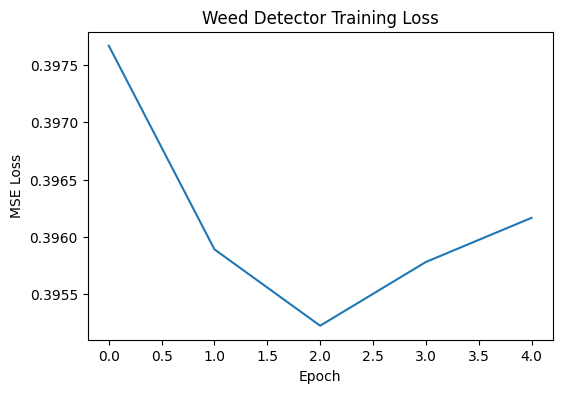

In [13]:
plt.figure(figsize=(6,4))
plt.plot(detector_history.history["loss"])
plt.title("Weed Detector Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


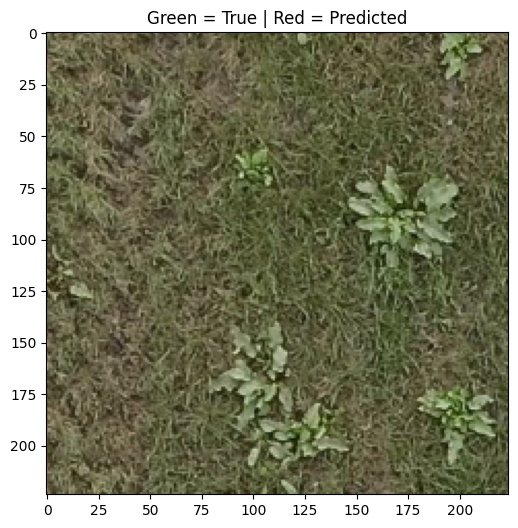

In [14]:
import matplotlib.patches as patches

# Take one batch
for imgs, true_bboxes in weed_ds.take(1):

    preds = detector_model.predict(imgs)

    img = imgs[0].numpy()
    true_box = true_bboxes[0].numpy()
    pred_box = preds[0]

    fig, ax = plt.subplots(1, figsize=(6,6))
    ax.imshow(img)

    # TRUE BOX (Green)
    x, y, w, h = true_box
    rect = patches.Rectangle(
        (x*224, y*224),
        w*224,
        h*224,
        linewidth=2,
        edgecolor='green',
        facecolor='none'
    )
    ax.add_patch(rect)

    # PREDICTED BOX (Red)
    x, y, w, h = pred_box
    rect = patches.Rectangle(
        (x*224, y*224),
        w*224,
        h*224,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    plt.title("Green = True | Red = Predicted")
    plt.show()

    break

In [18]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for imgs, labels in plant_val_ds:
    preds = plant_model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

unique_labels = np.unique(y_true)

print("Unique labels in validation:", unique_labels)

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(plant_classes)),
    target_names=plant_classes,
    zero_division=0
))

Unique labels in validation: [7]
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00         0
                     Pepper__bell___healthy       0.00      0.00      0.00         0
                      Potato___Early_blight       0.00      0.00      0.00         0
                       Potato___Late_blight       0.00      0.00      0.00         0
                           Potato___healthy       0.00      0.00      0.00         0
                      Tomato_Bacterial_spot       0.00      0.00      0.00         0
                        Tomato_Early_blight       0.00      0.00      0.00         0
                         Tomato_Late_blight       1.00      1.00      1.00        31
                           Tomato_Leaf_Mold       0.00      0.00      0.00         0
                  Tomato_Septoria_leaf_spot       0.00      0.00      0.00         0
Tomato_Spider_mites_Two_spotted

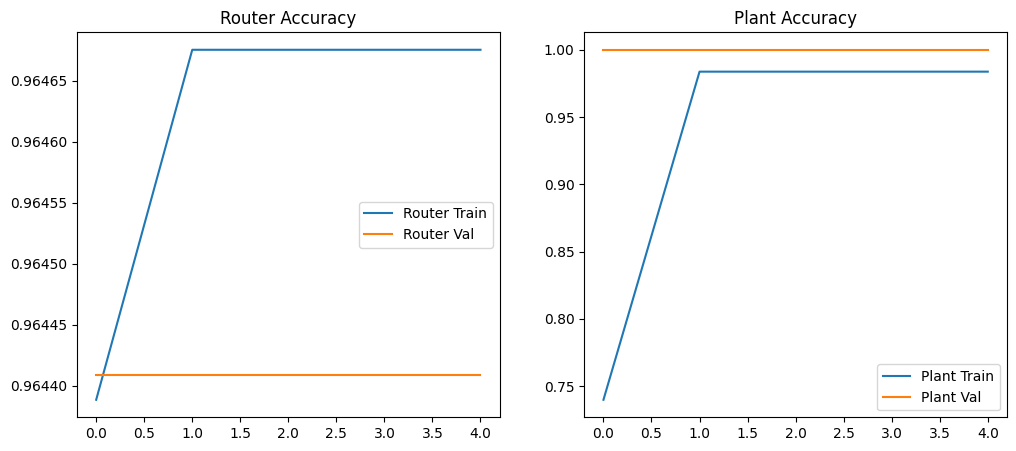

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(router_history.history["accuracy"], label="Router Train")
plt.plot(router_history.history["val_accuracy"], label="Router Val")
plt.legend(); plt.title("Router Accuracy")

plt.subplot(1,2,2)
plt.plot(plant_history.history["accuracy"], label="Plant Train")
plt.plot(plant_history.history["val_accuracy"], label="Plant Val")
plt.legend(); plt.title("Plant Accuracy")

plt.show()

# 2nd try

In [19]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [20]:
PLANT_ROOT = "/kaggle/input/datasets/emmarex/plantdisease/plantvillage/PlantVillage"

plant_paths = []
plant_labels = []
plant_classes = sorted(os.listdir(PLANT_ROOT))
class_map = {c:i for i,c in enumerate(plant_classes)}

for cls in plant_classes:
    folder = os.path.join(PLANT_ROOT, cls)
    for img in os.listdir(folder):
        if img.endswith(".jpg"):
            plant_paths.append(os.path.join(folder, img))
            plant_labels.append(class_map[cls])

print("Plant Images:", len(plant_paths))
print("Plant Classes:", len(plant_classes))

Plant Images: 154
Plant Classes: 15


In [21]:
WEED_ROOT = "/kaggle/input/datasets/jaidalmotra/weed-detection/train"
ANNOT_FILE = os.path.join(WEED_ROOT, "_annotations.coco.json")

with open(ANNOT_FILE) as f:
    coco = json.load(f)

image_map = {img["id"]: img for img in coco["images"]}

weed_paths = []
weed_bboxes = []

for ann in coco["annotations"]:
    img_info = image_map[ann["image_id"]]
    filename = img_info["file_name"]
    img_path = os.path.join(WEED_ROOT, filename)
    
    weed_paths.append(img_path)
    weed_bboxes.append(ann["bbox"])  # [x,y,w,h]

weed_bboxes = np.array(weed_bboxes, dtype=np.float32)

print("Weed Images:", len(weed_paths))

Weed Images: 4199


In [22]:
router_paths = plant_paths + weed_paths
router_labels = [0]*len(plant_paths) + [1]*len(weed_paths)

r_train_x, r_val_x, r_train_y, r_val_y = train_test_split(
    router_paths,
    router_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [23]:
def preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, 3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

def make_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

router_train_ds = make_ds(r_train_x, r_train_y)
router_val_ds   = make_ds(r_val_x, r_val_y)

In [24]:
def build_router():
    inp = keras.Input(shape=(224,224,3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inp, out)

router_model = build_router()

router_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

router_history = router_model.fit(
    router_train_ds,
    validation_data=router_val_ds,
    epochs=5
)

Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 45s 230ms/step - accuracy: 0.9538 - loss: 0.1849 - val_accuracy: 0.9575 - val_loss: 0.1873
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9651 - loss: 0.1619 - val_accuracy: 0.9575 - val_loss: 0.1824
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9692 - loss: 0.1445 - val_accuracy: 0.9575 - val_loss: 0.1794
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9677 - loss: 0.1443 - val_accuracy: 0.9575 - val_loss: 0.1973
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9684 - loss: 0.1488 - val_accuracy: 0.9575 - val_loss: 0.1878


In [25]:
p_train_x, p_val_x, p_train_y, p_val_y = train_test_split(
    plant_paths,
    plant_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

plant_train_ds = make_ds(p_train_x, p_train_y)
plant_val_ds   = make_ds(p_val_x, p_val_y)

def build_plant():
    inp = keras.Input(shape=(224,224,3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(len(plant_classes), activation="softmax")(x)
    
    return keras.Model(inp, out)

plant_model = build_plant()

plant_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

plant_history = plant_model.fit(
    plant_train_ds,
    validation_data=plant_val_ds,
    epochs=5
)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 5s/step - accuracy: 0.5260 - loss: 1.7875 - val_accuracy: 1.0000 - val_loss: 0.0602
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9820 - loss: 0.1488 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9820 - loss: 0.1548 - val_accuracy: 1.0000 - val_loss: 3.4431e-04
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9914 - loss: 0.0912 - val_accuracy: 1.0000 - val_loss: 1.2087e-04
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9800 - loss: 0.2055 - val_accuracy: 1.0000 - val_loss: 9.8920e-05


In [26]:
def preprocess_bbox(path, bbox):
    img_raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_raw, 3)

    original_shape = tf.cast(tf.shape(img), tf.float32)
    orig_h = original_shape[0]
    orig_w = original_shape[1]

    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0

    bbox = tf.cast(bbox, tf.float32)

    x = bbox[0] / orig_w
    y = bbox[1] / orig_h
    w = bbox[2] / orig_w
    h = bbox[3] / orig_h

    bbox = tf.stack([x, y, w, h])

    return img, bbox

weed_ds = tf.data.Dataset.from_tensor_slices((weed_paths, weed_bboxes))
weed_ds = weed_ds.map(preprocess_bbox, num_parallel_calls=AUTOTUNE)
weed_ds = weed_ds.shuffle(500).batch(BATCH_SIZE).prefetch(AUTOTUNE)

def build_detector():
    inp = keras.Input(shape=(224,224,3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    bbox_out = layers.Dense(4, activation="sigmoid")(x)
    
    return keras.Model(inp, bbox_out)

detector_model = build_detector()

detector_model.compile(
    optimizer="adam",
    loss="mse"
)

detector_history = detector_model.fit(weed_ds, epochs=5)

Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - loss: 0.0512
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0474
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0464
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0472
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0459


In [27]:
def preprocess_bbox(path, bbox):
    img_raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_raw, 3)

    original_shape = tf.cast(tf.shape(img), tf.float32)
    orig_h = original_shape[0]
    orig_w = original_shape[1]

    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0

    bbox = tf.cast(bbox, tf.float32)

    x = bbox[0] / orig_w
    y = bbox[1] / orig_h
    w = bbox[2] / orig_w
    h = bbox[3] / orig_h

    bbox = tf.stack([x, y, w, h])

    return img, bbox

weed_ds = tf.data.Dataset.from_tensor_slices((weed_paths, weed_bboxes))
weed_ds = weed_ds.map(preprocess_bbox, num_parallel_calls=AUTOTUNE)
weed_ds = weed_ds.shuffle(500).batch(BATCH_SIZE).prefetch(AUTOTUNE)

def build_detector():
    inp = keras.Input(shape=(224,224,3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    bbox_out = layers.Dense(4, activation="sigmoid")(x)
    
    return keras.Model(inp, bbox_out)

detector_model = build_detector()

detector_model.compile(
    optimizer="adam",
    loss="mse"
)

detector_history = detector_model.fit(weed_ds, epochs=5)

Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 105ms/step - loss: 0.0537
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0474
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0463
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0492
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0468


In [28]:
y_true = []
y_pred = []

for imgs, labels in plant_val_ds:
    preds = plant_model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Unique Predictions:", np.unique(y_pred))

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(plant_classes)),
    target_names=plant_classes,
    zero_division=0
))

Unique Predictions: [7]
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00         0
                     Pepper__bell___healthy       0.00      0.00      0.00         0
                      Potato___Early_blight       0.00      0.00      0.00         0
                       Potato___Late_blight       0.00      0.00      0.00         0
                           Potato___healthy       0.00      0.00      0.00         0
                      Tomato_Bacterial_spot       0.00      0.00      0.00         0
                        Tomato_Early_blight       0.00      0.00      0.00         0
                         Tomato_Late_blight       1.00      1.00      1.00        31
                           Tomato_Leaf_Mold       0.00      0.00      0.00         0
                  Tomato_Septoria_leaf_spot       0.00      0.00      0.00         0
Tomato_Spider_mites_Two_spotted_spider_m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


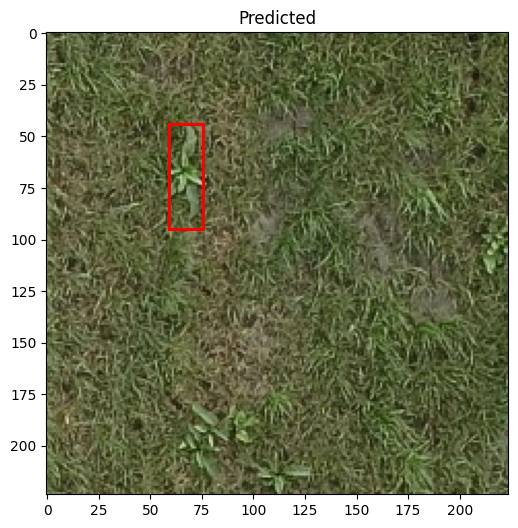

In [40]:
import matplotlib.patches as patches

for imgs, true_bboxes in weed_ds.take(1):
    preds = detector_model.predict(imgs)

    img = imgs[0].numpy()
    true_box = true_bboxes[0].numpy()
    pred_box = preds[0]

    fig, ax = plt.subplots(1, figsize=(6,6))
    ax.imshow(img)

    # TRUE BOX (Green)
    x,y,w,h = true_box
    rect = patches.Rectangle((x*224,y*224),
                             w*224,h*224,
                             linewidth=2,
                             edgecolor='red',
                             facecolor='none')
    ax.add_patch(rect)

    # PRED BOX (Red)
    #x,y,w,h = pred_box
    #rect = patches.Rectangle((x*224,y*224),
                            # w*224,h*224,
                             #linewidth=2,
                             #edgecolor='red',
                             #facecolor='none')
    ax.add_patch(rect)

    plt.title("Predicted")
    plt.show()
    break

In [32]:
def full_pipeline(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img,3)
    img = tf.image.resize(img, IMG_SIZE)/255.0
    img = tf.expand_dims(img,0)
    
    task = router_model.predict(img)[0][0]
    
    if task < 0.5:
        print("Detected: Plant")
        disease = plant_model.predict(img)
        print("Disease:", plant_classes[np.argmax(disease)])
    else:
        print("Detected: Weed")
        bbox = detector_model.predict(img)[0]
        print("BBox (normalized):", bbox)

In [33]:
# Example: test with a plant image
test_image = plant_paths[0]
full_pipeline(test_image)

2026-02-25 05:18:39.610364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 05:18:39.745874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 05:18:40.416077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 05:18:40.551722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 05:18:40.686961: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Detected: Weed
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
BBox (normalized): [0.45574677 0.46799228 0.14448422 0.14873293]


In [34]:
test_image = weed_paths[0]
full_pipeline(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Detected: Weed
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
BBox (normalized): [0.4549794  0.4686217  0.14431082 0.14864556]


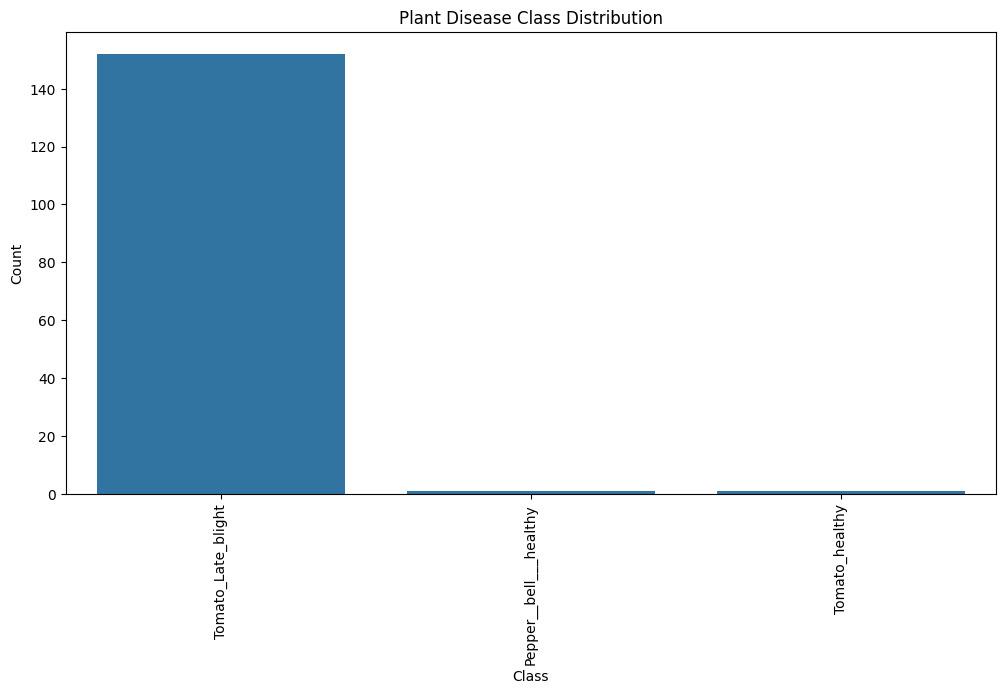

In [41]:
from collections import Counter
import pandas as pd

plant_count = Counter(plant_labels)

df_plant = pd.DataFrame({
    "Class": [plant_classes[i] for i in plant_count.keys()],
    "Count": plant_count.values()
}).sort_values("Count", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=df_plant, x="Class", y="Count")
plt.xticks(rotation=90)
plt.title("Plant Disease Class Distribution")
plt.show()

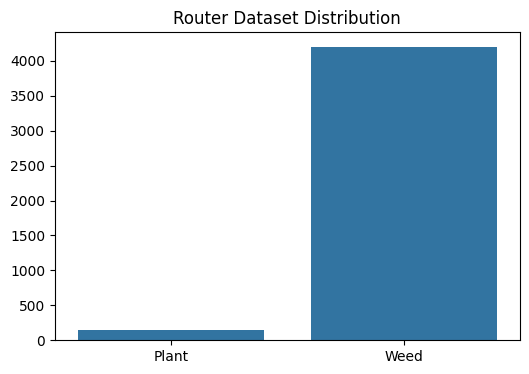

In [42]:
router_count = Counter(router_labels)

plt.figure(figsize=(6,4))
sns.barplot(x=["Plant","Weed"],
            y=[router_count[0], router_count[1]])
plt.title("Router Dataset Distribution")
plt.show()

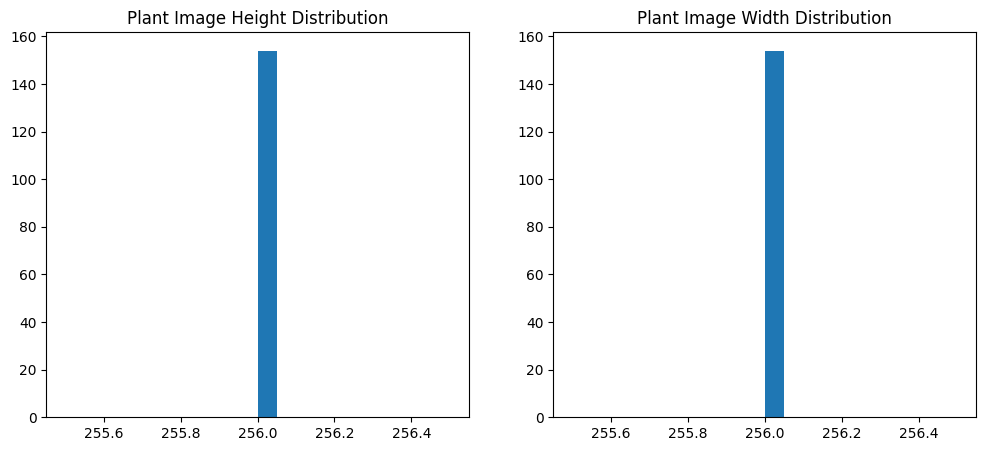

In [43]:
plant_heights = []
plant_widths = []

for path in plant_paths[:500]:  # sample subset
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img,3)
    h, w, _ = img.shape
    plant_heights.append(h)
    plant_widths.append(w)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(plant_heights, bins=20)
plt.title("Plant Image Height Distribution")

plt.subplot(1,2,2)
plt.hist(plant_widths, bins=20)
plt.title("Plant Image Width Distribution")

plt.show()

In [44]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_norm,
            cmap="Greens",
            xticklabels=plant_classes,
            yticklabels=plant_classes)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

NameError: name 'cm' is not defined

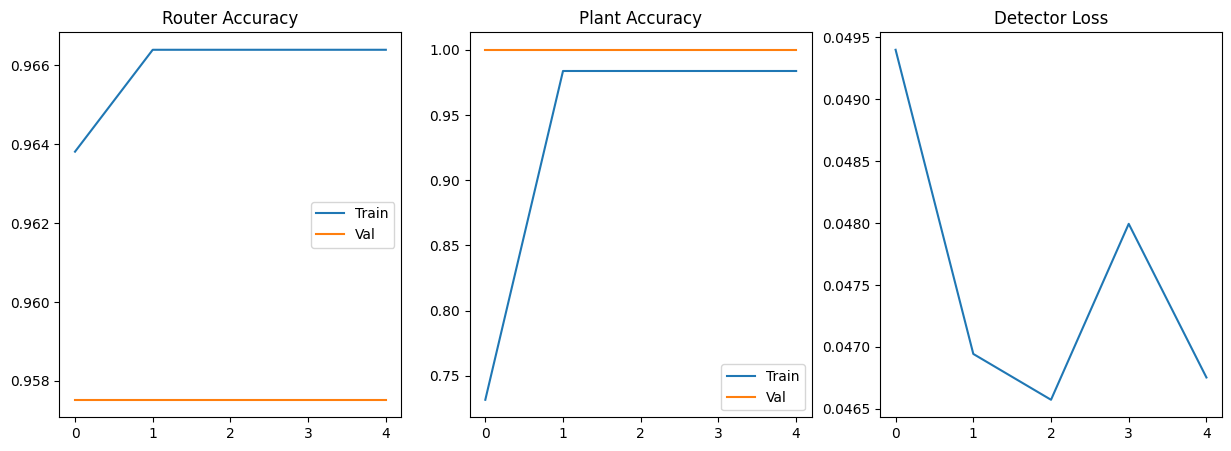

In [45]:
plt.figure(figsize=(15,5))

# Router
plt.subplot(1,3,1)
plt.plot(router_history.history["accuracy"], label="Train")
plt.plot(router_history.history["val_accuracy"], label="Val")
plt.title("Router Accuracy")
plt.legend()

# Plant
plt.subplot(1,3,2)
plt.plot(plant_history.history["accuracy"], label="Train")
plt.plot(plant_history.history["val_accuracy"], label="Val")
plt.title("Plant Accuracy")
plt.legend()

# Detector
plt.subplot(1,3,3)
plt.plot(detector_history.history["loss"])
plt.title("Detector Loss")

plt.show()

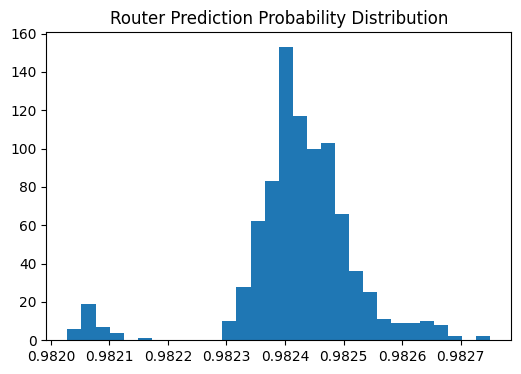

In [46]:
router_probs = []

for imgs, _ in router_val_ds:
    preds = router_model.predict(imgs, verbose=0)
    router_probs.extend(preds.flatten())

plt.figure(figsize=(6,4))
plt.hist(router_probs, bins=30)
plt.title("Router Prediction Probability Distribution")
plt.show()

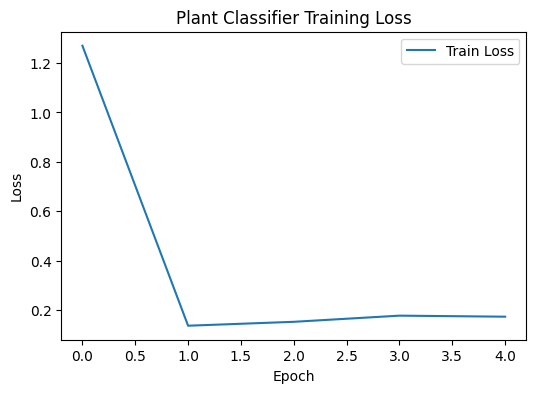

In [48]:
plt.figure(figsize=(6,4))

plt.plot(plant_history.history["loss"], label="Train Loss")

plt.title("Plant Classifier Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()